# Lesson 6: Finding Influential Papers with PageRank

**Duration:** ~5 minutes  
**Module:** 5 - GDS with Python  
**Dataset:** Cora Citation Network

## What You'll Learn

- How PageRank identifies influential papers
- How to run PageRank and interpret results
- How to find cross-disciplinary influential papers

## What Does PageRank Measure?

PageRank identifies influential papers based on:
- **Not just citation count** — a paper cited by 10 influential papers ranks higher than one cited by 100 obscure papers
- **Recursive influence** — papers cited by OTHER influential papers score higher
- **Network position** — reveals foundational papers that shaped entire fields

**Business value:** "If you're entering a research field, PageRank tells you which papers you MUST read—not just popular papers, but truly foundational ones."

## Setup: Connect and Get Projection

In [14]:
import os
import pandas as pd
from IPython.display import display
from graphdatascience import GraphDataScience
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# Load environment variables
load_dotenv()

uri = os.getenv('NEO4J_URI')
username = os.getenv('NEO4J_USERNAME')
password = os.getenv('NEO4J_PASSWORD')

# Create GDS client
gds = GraphDataScience(uri, auth=(username, password))

print(f"Connected to GDS version: {gds.version()}")

Connected to GDS version: 2.25.0


In [15]:
# Get the existing projection from Lesson 5
G = gds.graph.get("cora-graph")

print(f"Retrieved graph: {G.name()}")
print(f"  Nodes: {G.node_count():,}")
print(f"  Relationships: {G.relationship_count():,}")

Retrieved graph: cora-graph
  Nodes: 2,708
  Relationships: 10,858


## Run PageRank

We'll run PageRank and write results back to the database so we can query them with Cypher.

In [16]:
# Run PageRank and write results back to the database
PR_result = gds.pageRank.write(
    G,
    writeProperty='pageRank',
    maxIterations=20,
    dampingFactor=0.85
)

print(f"Computed PageRank for {PR_result['nodePropertiesWritten']:,} papers")
print(f"  Iterations ran: {PR_result['ranIterations']}")
print(f"  Compute time: {PR_result['computeMillis']}ms")

Computed PageRank for 2,708 papers
  Iterations ran: 20
  Compute time: 14ms


In [17]:
if PR_result['ranIterations'] == 20:  # maxIterations default
    print("Warning: may not have converged!")
    print("Consider increasing maxIterations")

Consider increasing maxIterations


Let's run it again with 100 max iterations:

In [18]:
# Run PageRank and write results back to the database
PR_result = gds.pageRank.write(
    G,
    writeProperty='pageRank',
    maxIterations=100,
    dampingFactor=0.85
)

print(f"Computed PageRank for {PR_result['nodePropertiesWritten']:,} papers")
print(f"  Iterations ran: {PR_result['ranIterations']}")
print(f"  Compute time: {PR_result['computeMillis']}ms")

if PR_result['ranIterations'] == 20:  # maxIterations default
    print("Warning: may not have converged!")
    print("Consider increasing maxIterations")

Computed PageRank for 2,708 papers
  Iterations ran: 89
  Compute time: 51ms


Of course, we can always run it with stats first to ensure we're getting convergence.

In [19]:
result = gds.pageRank.stats(
    G,
    maxIterations=100,
    dampingFactor=0.85
)
print(result)

ranIterations                                                            89
didConverge                                                            True
centralityDistribution    {'p99': 3.757596969604492, 'min': 0.2919082641...
preProcessingMillis                                                       0
computeMillis                                                            52
postProcessingMillis                                                     10
configuration             {'jobId': '6a360293-e547-4341-ac87-e7e0b0338a4...
Name: 0, dtype: object


## Find Most Influential Papers

In [21]:
# Find top 10 papers by PageRank
top_papers = gds.run_cypher("""
    MATCH (p:Paper)
    WHERE p.pageRank IS NOT NULL
    RETURN p.paper_Id AS paperId,
           p.subject AS subject,
           p.pageRank AS pageRank
    ORDER BY pageRank DESC
    LIMIT 10
""")

print("Top 10 Most Influential Papers:")
display(top_papers)

Top 10 Most Influential Papers:


,paperId,subject,pageRank
0,35,Genetic_Algorithms,32.666616
1,1365,Neural_Networks,16.556646
2,3229,Neural_Networks,14.139130
3,6213,Reinforcement_Learning,13.710552
4,910,Neural_Networks,9.970536
5,4330,Probabilistic_Methods,8.420614
6,114,Reinforcement_Learning,7.479976
7,3231,Theory,7.331763
8,19621,Neural_Networks,7.164798
9,1272,Theory,6.760252


In [22]:
# PageRank distribution by subject
subject_influence = gds.run_cypher("""
    MATCH (p:Paper)
    WHERE p.pageRank IS NOT NULL
    RETURN p.subject AS subject,
           count(*) AS paperCount,
           avg(p.pageRank) AS avgPageRank,
           max(p.pageRank) AS maxPageRank
    ORDER BY avgPageRank DESC
""")

print("Influence by Subject Area:")
display(subject_influence)

Influence by Subject Area:


,subject,paperCount,avgPageRank,maxPageRank
0,Theory,351,1.063884,7.331763
1,Genetic_Algorithms,418,1.027687,32.666616
2,Reinforcement_Learning,217,1.027073,13.710552
3,Probabilistic_Methods,426,1.002734,8.420614
4,Rule_Learning,180,0.975028,6.488403
5,Neural_Networks,818,0.968289,16.556646
6,Case_Based,298,0.964417,6.390281


## Find Cross-Disciplinary Influential Papers

The most interesting papers are often those that bridge different research areas.

In [23]:
# Find influential papers that cite papers in different subjects
cross_discipline = gds.run_cypher("""
    MATCH (p:Paper)
    WHERE p.pageRank > 5
    MATCH (p)-[:CITES]->(cited:Paper)
    WHERE p.subject <> cited.subject
    RETURN 
        p.paper_Id AS paperId,
        p.subject AS sourceSubject,
        p.pageRank AS pageRank,
        cited.subject AS citedSubject,
        cited.pageRank AS citedPageRank
    ORDER BY p.pageRank DESC 
    LIMIT 10
""")

print("Top Influential Papers with Cross-Subject Citations:")
display(cross_discipline)

Top Influential Papers with Cross-Subject Citations:


,paperId,sourceSubject,pageRank,citedSubject,citedPageRank
0,3229,Neural_Networks,14.139130,Reinforcement_Learning,2.307546
1,6213,Reinforcement_Learning,13.710552,Genetic_Algorithms,5.569773
2,4330,Probabilistic_Methods,8.420614,Neural_Networks,1.506318
3,3231,Theory,7.331763,Case_Based,1.362300
4,3231,Theory,7.331763,Rule_Learning,3.466585
5,3231,Theory,7.331763,Case_Based,1.466380
6,3231,Theory,7.331763,Case_Based,3.296633
7,1272,Theory,6.760252,Neural_Networks,1.601837
8,1272,Theory,6.760252,Reinforcement_Learning,5.619878
9,2440,Rule_Learning,6.488403,Case_Based,1.310851


In [24]:
# Count cross-discipline citations for top papers
bridge_papers = gds.run_cypher("""
    MATCH (p:Paper)
    WHERE p.pageRank > 3
    MATCH (p)-[:CITES]->(cited:Paper)
    WITH p, 
         count(DISTINCT cited.subject) AS subjectsCited,
         count(cited) AS totalCitations
    WHERE subjectsCited > 1
    RETURN p.paper_Id AS paperId,
           p.subject AS subject,
           p.pageRank AS pageRank,
           subjectsCited,
           totalCitations
    ORDER BY subjectsCited DESC, pageRank DESC
    LIMIT 10
""")

print("Papers Citing Multiple Subject Areas:")
display(bridge_papers)

Papers Citing Multiple Subject Areas:


,paperId,subject,pageRank,subjectsCited,totalCitations
0,3231,Theory,7.331763,3,5
1,10796,Case_Based,3.537627,3,3
2,3229,Neural_Networks,14.139130,2,4
3,6213,Reinforcement_Learning,13.710552,2,3
4,4330,Probabilistic_Methods,8.420614,2,2
5,1272,Theory,6.760252,2,2
6,8703,Rule_Learning,4.006196,2,4
7,12576,Genetic_Algorithms,3.839919,2,4
8,35922,Probabilistic_Methods,3.511045,2,4
9,210871,Genetic_Algorithms,3.421335,2,5


We can see a histogram of these results with the following query, using matplotlib:

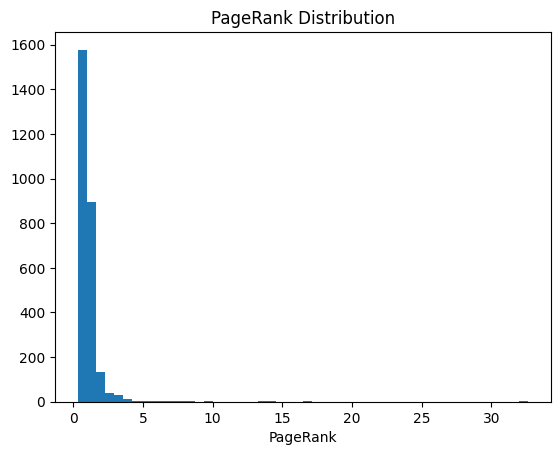

In [25]:
df = gds.run_cypher("MATCH (p:Paper) RETURN p.pageRank AS pr")
plt.hist(df['pr'], bins=50)
plt.xlabel('PageRank')
plt.title('PageRank Distribution')
plt.show()

## Interpretation

**What do these results mean?**

- Papers with PageRank > 5 are influential in this network
- Papers that cite multiple subject areas are **interdisciplinary bridges**
- High PageRank + multiple subjects cited = foundational interdisciplinary work

**Remember from Module 2:** We used PageRank to find influential fraudsters. Same algorithm, different domain!

## Summary

You've used PageRank to analyze the citation network:

- **Ran PageRank** to identify influential papers
- **Analyzed influence by subject** to see which fields have the most impact
- **Found cross-disciplinary papers** that bridge research areas

### Next Notebook

Use Betweenness Centrality to find "bridge papers" that connect different research communities.